In [1]:
!pip install tensorflow

In [9]:
import os
import cv2
import xml.etree.ElementTree as ET
from tqdm import tqdm
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Setup paths
images_path = 'images'
annotations_path = 'annotations'
output_path = 'cleaned_data'

# Create folders for each class
labels = ['with_mask', 'without_mask', 'mask_weared_incorrect']
for label in labels:
    os.makedirs(os.path.join(output_path, label), exist_ok=True)

# Loop through each XML file
for xml_file in tqdm(os.listdir(annotations_path)):
    if not xml_file.endswith('.xml'):
        continue

    xml_path = os.path.join(annotations_path, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_filename = root.find('filename').text
    image_path = os.path.join(images_path, image_filename)
    image = cv2.imread(image_path)

    if image is None:
        continue

    for obj in root.findall('object'):
        label = obj.find('name').text
        if label not in labels:
            continue

        bbox = obj.find('bndbox')
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))

        face = image[ymin:ymax, xmin:xmax]
        save_name = f"{xml_file[:-4]}_{xmin}_{ymin}.jpg"
        save_path = os.path.join(output_path, label, save_name)

        try:
            resized_face = cv2.resize(face, (128, 128))
            cv2.imwrite(save_path, resized_face)
        except:
            pass  # Ignore if resizing fails


100%|████████████████████████████████████████████████████████████████████████████████| 853/853 [01:56<00:00,  7.33it/s]


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    'cleaned_data',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'cleaned_data',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3259 images belonging to 3 classes.
Found 813 images belonging to 3 classes.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 output classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)


C:\Users\ramch\anaconda3\envs\maskcnn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ramch\anaconda3\envs\maskcnn\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8510 - loss: 0.3928 - val_accuracy: 0.9323 - val_loss: 0.2277
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.9384 - loss: 0.2195 - val_accuracy: 0.9225 - val_loss: 0.2385
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9394 - loss: 0.1959 - val_accuracy: 0.9373 - val_loss: 0.2010
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.9426 - loss: 0.1879 - val_accuracy: 0.9348 - val_loss: 0.2098
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.9383 - loss: 0.1838 - val_accuracy: 0.9336 - val_loss: 0.2257
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.9461 - loss: 0.1732 - val_accuracy: 0.9410 - val_loss: 0.2051
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.9374 - loss: 0.1652 - val_accuracy: 0.9373 - val_loss: 0.2013
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.9504 - loss: 0

In [13]:
model.save('mask_classifier_model.h5')


In [14]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions from the model
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

print("Classes:", val_generator.class_indices)
print(classification_report(val_generator.classes, y_pred, target_names=val_generator.class_indices.keys()))


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Classes: {'mask_weared_incorrect': 0, 'with_mask': 1, 'without_mask': 2}
                       precision    recall  f1-score   support

mask_weared_incorrect       0.00      0.00      0.00        24
            with_mask       0.79      0.81      0.80       646
         without_mask       0.18      0.19      0.19       143

             accuracy                           0.68       813
            macro avg       0.33      0.33      0.33       813
         weighted avg       0.66      0.68      0.67       813



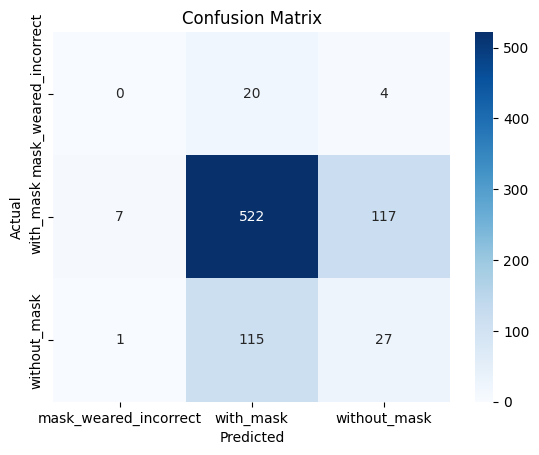

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(val_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [16]:
import os

test_path = 'cleaned_data/with_mask'  # Or try 'without_mask' or 'mask_weared_incorrect'
print("Available test images:", os.listdir(test_path)[:5])


Available test images: ['maksssksksss0_185_100.jpg', 'maksssksksss100_118_87.jpg', 'maksssksksss100_189_30.jpg', 'maksssksksss100_387_54.jpg', 'maksssksksss101_48_294.jpg']


In [17]:
import os

test_path = 'cleaned_data/without_mask'
print("Available test images:", os.listdir(test_path)[:5])


Available test images: ['maksssksksss0_325_90.jpg', 'maksssksksss0_79_105.jpg', 'maksssksksss104_167_91.jpg', 'maksssksksss104_2_105.jpg', 'maksssksksss104_304_131.jpg']


In [18]:
import os

test_path = 'cleaned_data/mask_weared_incorrect'
print("Available test images:", os.listdir(test_path)[:5])

Available test images: ['maksssksksss112_90_84.jpg', 'maksssksksss11_23_114.jpg', 'maksssksksss130_162_58.jpg', 'maksssksksss130_7_104.jpg', 'maksssksksss132_106_72.jpg']


In [19]:
def predict_image(img_path):
    from tensorflow.keras.preprocessing import image
    import numpy as np
    import matplotlib.pyplot as plt

    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = list(train_generator.class_indices.keys())[predicted_index]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted: {predicted_class}', fontsize=14)
    plt.show()
    return predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


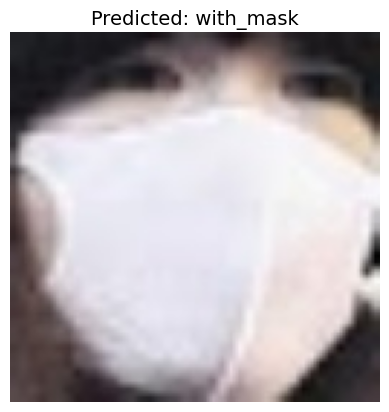

'with_mask'

In [20]:
predict_image('cleaned_data/with_mask/maksssksksss0_185_100.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


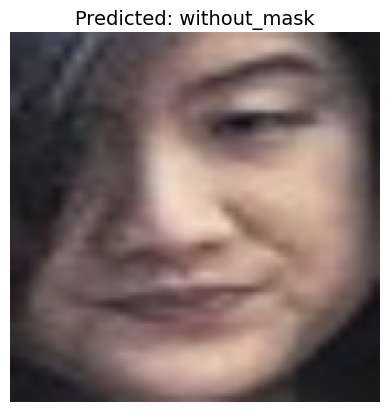

'without_mask'

In [21]:
predict_image('cleaned_data/without_mask/maksssksksss0_325_90.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


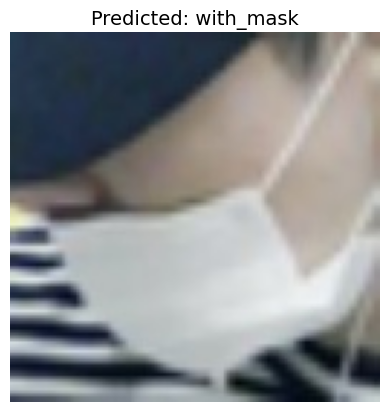

'with_mask'

In [22]:
predict_image('cleaned_data/mask_weared_incorrect/maksssksksss112_90_84.jpg')

In [29]:
# Load the trained model
model = load_model('mask_classifier_model.h5')

# Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Class labels
labels_dict = {0: 'with_mask', 1: 'without_mask', 2: 'mask_weared_incorrect'}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


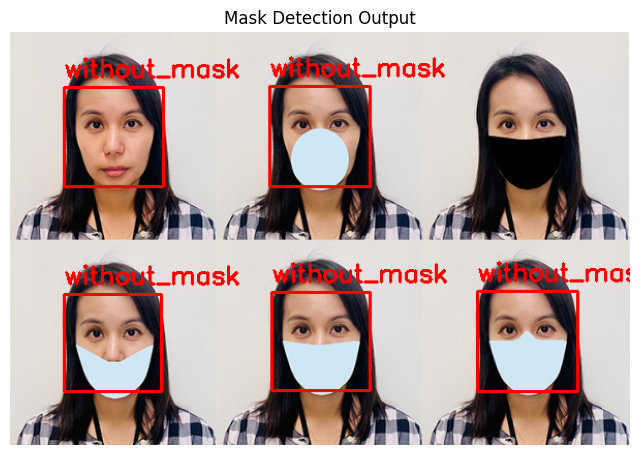

In [35]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('mask_classifier_model.h5')

# Load Haar cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
labels_dict = {0: 'with_mask', 1: 'without_mask', 2: 'mask_weared_incorrect'}

# Load your test image
image = cv2.imread('test1.jpg')  # 🔁 Replace with your test image
image = cv2.resize(image, (600, 400))
orig = image.copy()

# Convert to grayscale for detection
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Classify each detected face
for x, y, w, h in faces:
    face = image[y:y+h, x:x+w]
    try:
        resized = cv2.resize(face, (128, 128))
        normalized = resized / 255.0
        reshaped = np.reshape(normalized, (1, 128, 128, 3))
        result = model.predict(reshaped)
        label = labels_dict[np.argmax(result)]

        # Draw box and label
        color = (0, 255, 0) if label == 'with_mask' else (0, 0, 255) if label == 'without_mask' else (255, 255, 0)
        cv2.rectangle(orig, (x, y), (x+w, y+h), color, 2)
        cv2.putText(orig, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    except:
        continue

# Show output
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Mask Detection Output")
plt.show()
